In [64]:
import pandas as pd  

# Carregar o DataFrame do ficheiro .pkl  
df = pd.read_pickle("results/evaluation_output_.pkl")  

# Mostrar as primeiras linhas para ver o conteúdo  
print(df.head())  


   polyp_id            seq             seqs  \
0        22  p013_02_B_WLI  [p013_02_B_WLI]   
1        22  p013_02_B_WLI  [p013_02_B_WLI]   
2        22  p013_02_B_WLI  [p013_02_B_WLI]   
3        22  p013_02_B_WLI  [p013_02_B_WLI]   
4        22  p013_02_B_WLI  [p013_02_B_WLI]   

                                             img_fns  \
0  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
1  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
2  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
3  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
4  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   

                                             ann_fns      key gt_class  \
0  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        0   
1  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        0   
2  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        0   
3  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        0   
4  [/DATAS

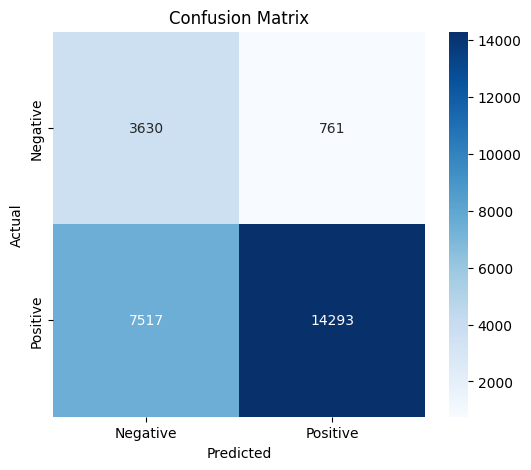

Accuracy: 0.6841
Precision: 0.9494
Recall: 0.6553
F1-score: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.83      0.47      4391
           1       0.95      0.66      0.78     21810

    accuracy                           0.68     26201
   macro avg       0.64      0.74      0.62     26201
weighted avg       0.84      0.68      0.72     26201



In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# Suponha que y_true e y_pred já estejam definidos
# y_true = [...]  # Valores reais
# y_pred = [...]  # Valores preditos

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 2. Métricas
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)  # Adicionando F1-score

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")  # Exibindo o F1-score

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


In [66]:
print(df["gt_class"].value_counts())  # Classes reais  
print(df["fold0_pred_class"].value_counts())  # Classes preditas  


gt_class
1    21810
0     4391
Name: count, dtype: int64
fold0_pred_class
1    15054
0    11147
Name: count, dtype: int64


In [67]:
df_errors = df[df["fold0_match"] == False]
print(df_errors)


       polyp_id            seq             seqs  \
1            22  p013_02_B_WLI  [p013_02_B_WLI]   
2            22  p013_02_B_WLI  [p013_02_B_WLI]   
5            22  p013_02_B_WLI  [p013_02_B_WLI]   
6            22  p013_02_B_WLI  [p013_02_B_WLI]   
8            22  p013_02_B_WLI  [p013_02_B_WLI]   
...         ...            ...              ...   
26187      1631     p871_02_01     [p871_02_01]   
26190      1631     p871_02_01     [p871_02_01]   
26192      1631     p871_02_01     [p871_02_01]   
26193      1631     p871_02_01     [p871_02_01]   
26194      1631     p871_02_01     [p871_02_01]   

                                                 img_fns  \
1      [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
2      [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
5      [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
6      [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
8      [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/CROP...   
...                        

In [68]:
print(df[["fold0_pred", "fold0_pred_class", "gt_class", "fold0_match"]].head(10))


                 fold0_pred  fold0_pred_class gt_class  fold0_match
0  [0.58641046, 0.41358954]                 0        0         True
1   [0.4793688, 0.52063125]                 1        0        False
2  [0.23013549, 0.76986456]                 1        0        False
3    [0.6367807, 0.3632192]                 0        0         True
4     [0.50613, 0.49386996]                 0        0         True
5   [0.27914125, 0.7208587]                 1        0        False
6   [0.43423688, 0.5657631]                 1        0        False
7  [0.69498175, 0.30501822]                 0        0         True
8    [0.3495431, 0.6504569]                 1        0        False
9   [0.4420174, 0.55798256]                 1        0        False


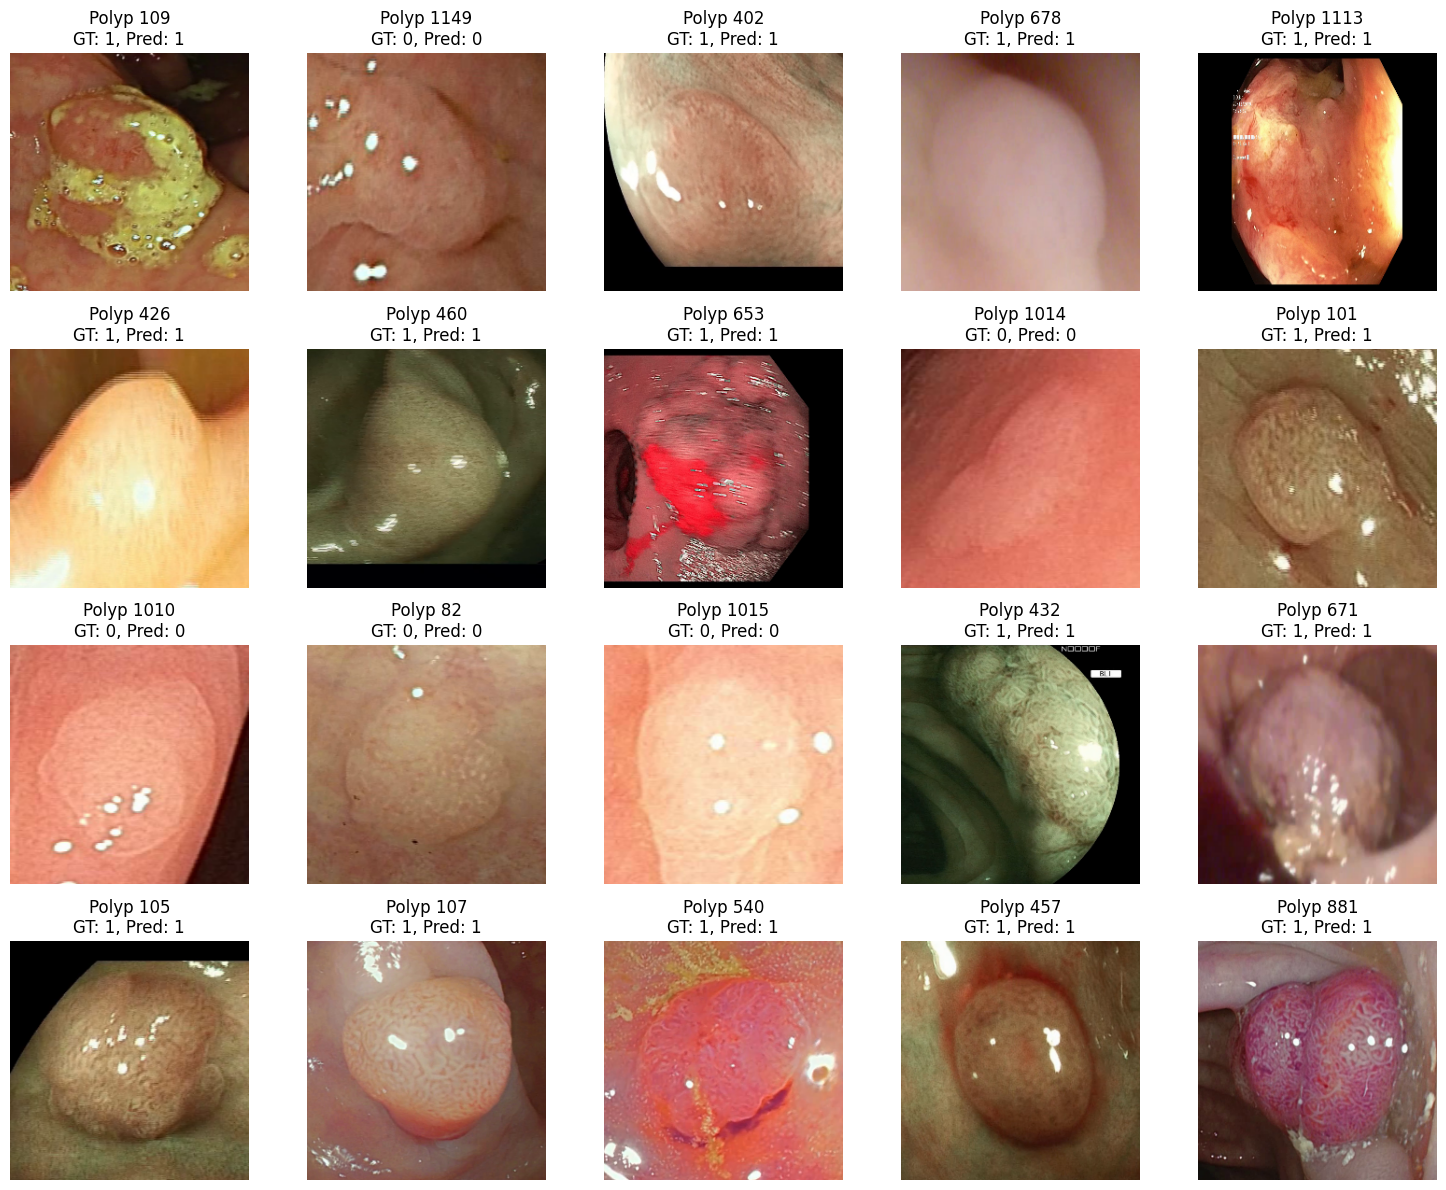

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2


# Filtrar apenas as previsões corretas
df_correct = df[df["fold0_match"] == True].sample(n=20, random_state=42)  # Seleciona 20 aleatórias

# Criar uma figura para mostrar múltiplas imagens
fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # Grid de 4 linhas x 5 colunas

# Percorrer cada amostra correta e exibir no grid
for ax, (_, sample) in zip(axes.flatten(), df_correct.iterrows()):
    image_path = sample["img_fns"][0]  # Caminho da imagem

    # Carregar a imagem
    image = cv2.imread(image_path)
    if image is None:
        ax.axis("off")
        ax.set_title("Erro ao carregar")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Converter para RGB
    ax.imshow(image)
    ax.set_title(f"Polyp {sample['polyp_id']}\nGT: {sample['gt_class']}, Pred: {sample['fold0_pred_class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


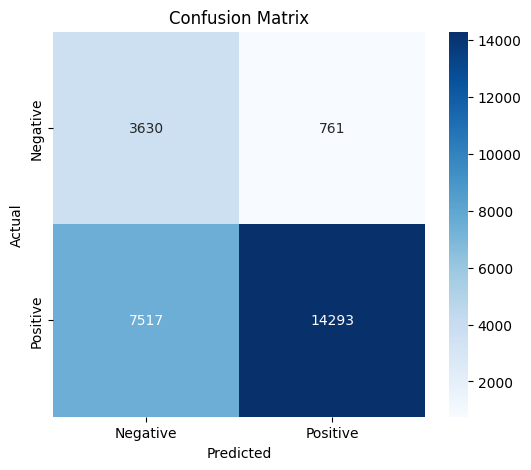

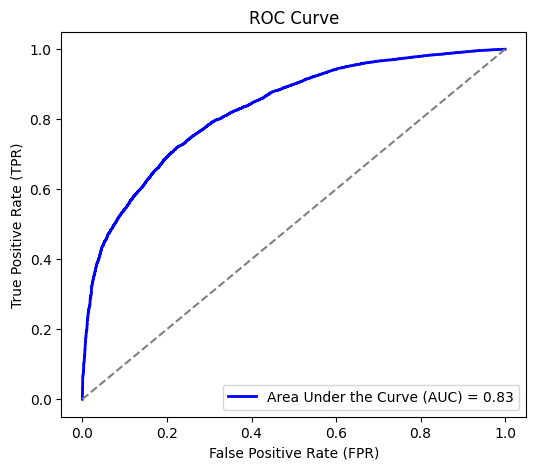

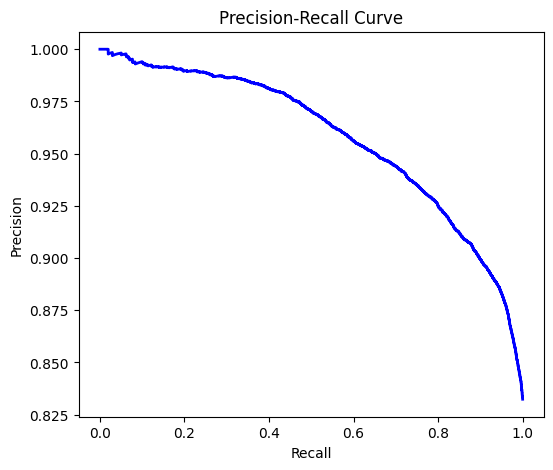

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.83      0.47      4391
           1       0.95      0.66      0.78     21810

    accuracy                           0.68     26201
   macro avg       0.64      0.74      0.62     26201
weighted avg       0.84      0.68      0.72     26201



In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report

# Extract the correct columns
y_true = df["gt_class"].astype(int)  # Convert to integer
y_pred = df["fold0_pred_class"].astype(int)  # Predicted classes
y_scores = df["fold0_pred"].apply(lambda x: x[1])  # Probability of the positive class

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"Area Under the Curve (AUC) = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color="blue", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# 4. Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred))


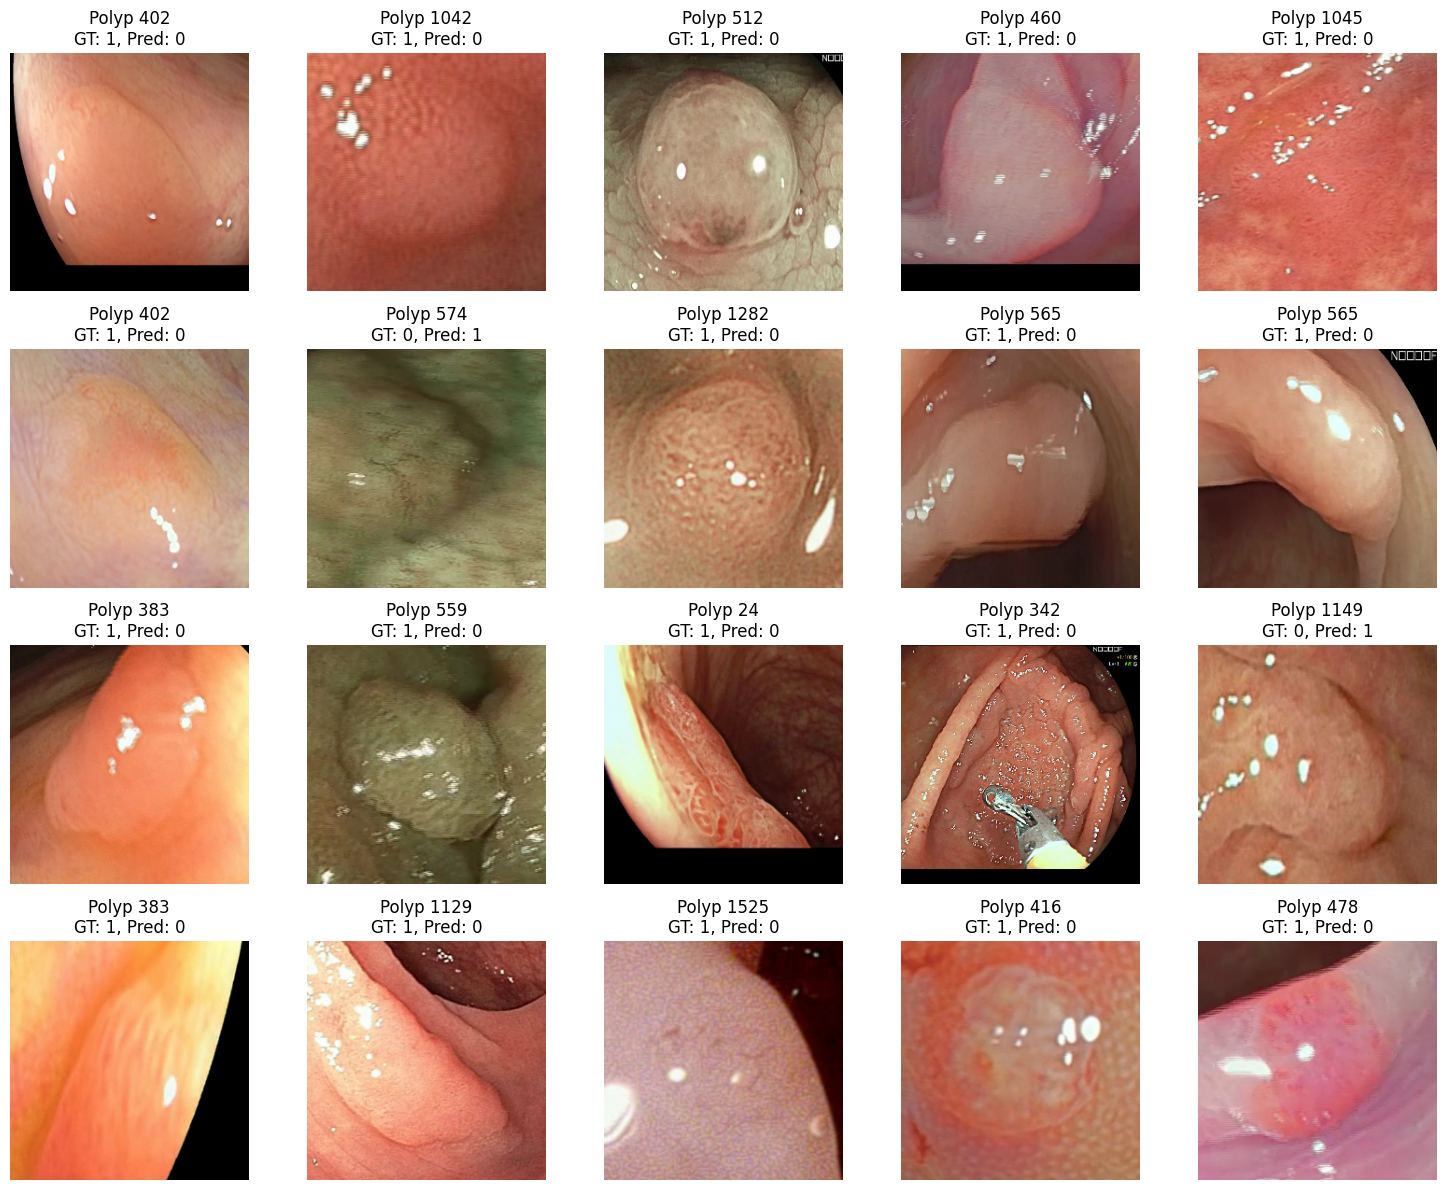

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Filter only misclassified polyps
df_misclassified = df[df["fold0_match"] == False].sample(n=20, random_state=42)  # Select 20 random samples

# Create a figure to display multiple images
fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 4 rows x 5 columns grid

# Loop through each misclassified sample and display in the grid
for ax, (_, sample) in zip(axes.flatten(), df_misclassified.iterrows()):
    image_path = sample["img_fns"][0]  # Image path

    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        ax.axis("off")
        ax.set_title("Error loading image")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    ax.imshow(image)
    ax.set_title(f"Polyp {sample['polyp_id']}\nGT: {sample['gt_class']}, Pred: {sample['fold0_pred_class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()
